# Biohub Cell Tracking During Development — 최종 정리 노트북

대회: [biohub-cell-tracking-during-development](https://www.kaggle.com/competitions/biohub-cell-tracking-during-development) · 팀 **BostonKaggle** · 마감 2026-09-29 23:59 UTC

이 노트북은 저장소에 남은 실험 산출물과 대회 종료 후 Kaggle API에서 받은 제출 기록만으로 실행된다. 새 학습·추론·제출은 하지 않는다.

| 절 | 내용 |
|---|---|
| 0 | 한눈에 보는 결과 |
| 1 | 데이터 분석: 학습 영상 199개, 이미지 메타데이터, 희소 GT |
| 2 | 평가 지표 |
| 3 | 제출 이력: Public vs Private, 리더보드 위치 |
| 4 | 최종 파이프라인(X138 계열) 구조 |
| 5 | XH00~XH08 후처리 변형 실험 |
| 6 | 오류 진단: 199개 영상 전수 재채점(XH10) |
| 7 | 사건 단위 추적(XH09) |
| 8 | 자체 기준선 학습(XH11) |
| 9 | 교훈과 다음 연구 |

**표기 원칙.** Kaggle 점수는 소수 셋째 자리까지만 공개된다. 학습 영상 진단 점수는 기존 가중치의 학습 데이터와 겹칠 수 있으므로 *개발 진단*이지 독립 검증이 아니다.

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# The analysis reads experiment artifacts from the original workbench repository.
ROOT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / 'AGENTS.md').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Run this notebook inside the original workbench repository; '
                            'its experiment artifacts are not included here (see README).')
XH = ROOT / 'experiments_0940/x138_review_2026_09_24'
DATA = ROOT / 'notebooks/final_report/snapshots'
GT_DIR = XH / 'labelled_replay_2026_09_25/gt_index/output_v2/xh09_gt_index'
META = ROOT / 'experiments_0940/performance_2026_09_12/runs/s0_metadata/output_v1/s0_metadata/train_metadata_inventory.json'
CENSUS = XH / 'full_census_2026_09_25'

# Palette: validated categorical order (blue, orange, aqua, yellow) + neutral ink.
C = dict(blue='#2a78d6', orange='#eb6834', aqua='#1baf7a', yellow='#eda100', red='#e34948',
         ink='#0b0b0b', ink2='#52514e', muted='#8a8984', grid='#e4e3df', surface='#fcfcfb')
FAMILY_COLOR = {'44b6': C['blue'], '6bba': C['orange']}
plt.rcParams.update({
    'figure.facecolor': C['surface'], 'axes.facecolor': C['surface'], 'savefig.facecolor': C['surface'],
    'axes.edgecolor': C['muted'], 'axes.labelcolor': C['ink2'], 'xtick.color': C['ink2'], 'ytick.color': C['ink2'],
    'text.color': C['ink'], 'axes.titlecolor': C['ink'], 'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'axes.labelsize': 9, 'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8, 'legend.frameon': False,
    'axes.grid': True, 'grid.color': C['grid'], 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 110, 'lines.linewidth': 2,
})
pd.set_option('display.width', 160, 'display.max_columns', 30)

def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()

def load(path):
    return json.loads(Path(path).read_text())

print('workbench artifacts found')

workbench artifacts found


## 0. 한눈에 보는 결과

In [2]:
subs = pd.DataFrame(load(DATA / 'kaggle_submissions_snapshot.json'))
subs['date'] = pd.to_datetime(subs['date'])
for col in ['publicScore', 'privateScore']:
    subs[col] = pd.to_numeric(subs[col], errors='coerce')
subs['scored'] = subs['publicScore'].notna() & subs['errorDescription'].fillna('').eq('')
subs['tag'] = subs['description'].str.extract(r'^(XH\d\d|GF01|S\d+[AB]?|P18|C\d)')[0]
subs.loc[subs['description'].str.contains('LB-0.920'), 'tag'] = 'v17'

lb = pd.read_csv(DATA / 'public_leaderboard_final.csv')
ours = lb[lb['TeamName'] == 'BostonKaggle'].iloc[0]
scored = subs[subs['scored']]
SELECTED = {56526964: 'XH00', 56527842: 'XH04'}   # final selection made in the Kaggle UI
sel = scored[scored['ref'].astype(int).isin(SELECTED)]
best_priv = scored.loc[scored['privateScore'].idxmax()]

summary = pd.DataFrame([
    ('제출 수(전체 / 정상 채점)', f"{len(subs)} / {len(scored)}"),
    ('Public 최고점', f"{scored['publicScore'].max():.3f}"),
    ('Public 리더보드 순위', f"{int(ours['Rank'])} / {len(lb)} 팀 (상위 {ours['Rank'] / len(lb):.1%})"),
    ('최종 선택 2개', ', '.join(f"{SELECTED[int(r)]} (Private {p:.3f})" for r, p in zip(sel['ref'], sel['privateScore']))),
    ('전체 제출 중 Private 최고점', f"{best_priv['privateScore']:.3f} — {best_priv['tag']} (ref {best_priv['ref']})"),
    ('리더보드 1위 Public', f"{lb['Score'].max():.3f}"),
], columns=['항목', '값'])
display(summary.style.hide(axis='index'))

항목,값
제출 수(전체 / 정상 채점),49 / 37
Public 최고점,0.953
Public 리더보드 순위,673 / 4020 팀 (상위 16.7%)
최종 선택 2개,"XH04 (Private 0.917), XH00 (Private 0.917)"
전체 제출 중 Private 최고점,0.920 — XH08 (ref 56554840)
리더보드 1위 Public,0.978


**요약**

- 공개 X138 계열 파이프라인을 정확히 재현해 Public **0.953**에 도달했다. 이후 후처리 변형 8개는 Public 0.953을 넘지 못했다.
- 최종 선택(XH00, XH04)의 Private 점수는 **0.917**이다. 제출 기록상 Private 최고점은 head 배율 1.25를 쓴 XH08의 **0.920**이었다. 다만 소수 셋째 자리 차이라서 사후에 이를 확실한 우위로 해석하기는 어렵다.
- 199개 학습 영상 진단에서 가장 큰 약점은 **분열(division) 정확도**였다. Division Jaccard 0.11, precision 27%, recall 16%이다. 그다음은 첫 motion 재연결이 기존 정답 연결을 깨는 현상이었다.

## 1. 데이터 분석

### 1.1 영상 구성과 이미지 메타데이터

학습 데이터는 두 가족(family) `44b6`, `6bba`의 3D+시간 형광 영상 199개다. 각 영상은 OME-Zarr(`T, Z, Y, X`, uint16) 형식이다. 아래 정보는 Kaggle에서 메타데이터만 읽어 만든 인벤토리(`train_metadata_inventory.json`)에서 가져왔다. 이미지 voxel은 읽지 않았다.

In [3]:
meta = load(META)
rows = []
for r in meta['records']:
    root = r['image']['metadata']['zarr.json']['value']['attributes']
    arr = r['image']['metadata']['0/zarr.json']['value']
    scale = root['multiscales'][0]['datasets'][0]['coordinateTransformations'][0]['scale']
    q = root.get('image_statistics', {}).get('quantiles', {})
    T, Z, Y, X = arr['shape']
    rows.append(dict(dataset=r['dataset'], family=r['family'], T=T, Z=Z, Y=Y, X=X,
                     sz=scale[1], sy=scale[2], sx=scale[3],
                     q01=q.get('0.01'), q50=None, q99=q.get('0.99'), qmax=q.get('1.0')))
img = pd.DataFrame(rows).drop(columns='q50')
img['volume_um3'] = img.Z * img.sz * img.Y * img.sy * img.X * img.sx
img['dyn_range'] = img.q99 / img.q01

fam = img.groupby('family').agg(
    movies=('dataset', 'size'),
    frames=('T', lambda s: f"{s.min()}–{s.max()}"),
    zyx=('Z', lambda s: ', '.join(sorted({f"{z}×{y}×{x}" for z, y, x in zip(s, img.loc[s.index, 'Y'], img.loc[s.index, 'X'])}))),
    voxel_um=('sz', lambda s: ', '.join(sorted({f"{a}×{b}×{c}" for a, b, c in zip(s, img.loc[s.index, 'sy'], img.loc[s.index, 'sx'])}))),
    q99_median=('q99', 'median'),
    q99_over_q01_median=('dyn_range', 'median'),
)
display(fam)

,movies,frames,zyx,voxel_um,q99_median,q99_over_q01_median
family,,,,,,
44b6,71,100–100,64×256×256,1.625×0.40625×0.40625,1958.277778,37.690000
6bba,128,100–100,64×256×256,1.625×0.40625×0.40625,836.094444,28.092632


- 두 가족 모두 모든 영상이 100프레임, 64×256×256 voxel, 같은 voxel 크기다. 차이는 영상 내용(세포 밀도·밝기)에 있다. Z축 voxel은 XY보다 4배 길다(1.625 µm 대 0.40625 µm). 그래서 거리 계산은 반드시 µm 단위로 해야 한다. voxel 단위 거리는 Z 방향 이동을 4배 과소평가한다.
- 밝기 분위수(q99/q01)는 영상마다 크게 다르다. 그래서 영상별 정규화가 필요했다. 아래 그림이 그 분포다.

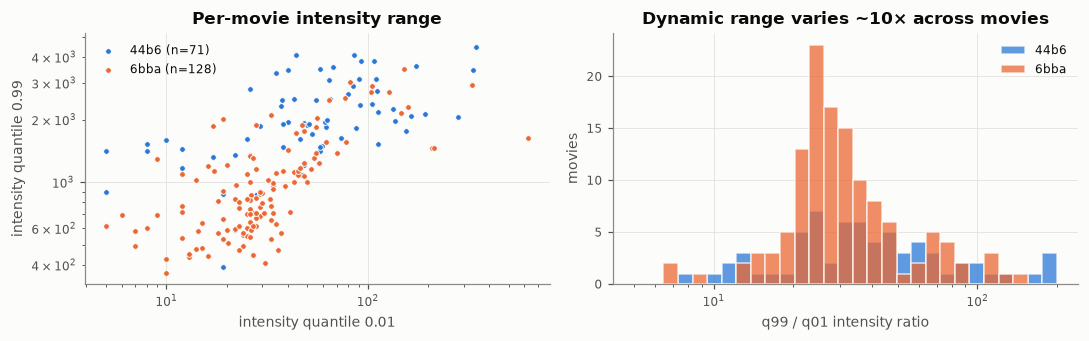

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for f, g in img.groupby('family'):
    axes[0].scatter(g.q01, g.q99, s=14, color=FAMILY_COLOR[f], label=f"{f} (n={len(g)})", edgecolor=C['surface'], linewidth=0.6)
    axes[1].hist(g.q99 / g.q01, bins=np.geomspace(5, 200, 30), color=FAMILY_COLOR[f], alpha=0.75, label=f, edgecolor=C['surface'])
axes[0].set(xscale='log', yscale='log', xlabel='intensity quantile 0.01', ylabel='intensity quantile 0.99', title='Per-movie intensity range')
axes[1].set(xscale='log', xlabel='q99 / q01 intensity ratio', ylabel='movies', title='Dynamic range varies ~10× across movies')
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

### 1.2 정답(GT) 그래프: 매우 희소한 주석

GT는 세포 중심점(node)과 시간상 연결(edge)로 이루어진 계보 그래프다. 한 영상 안의 세포 수만 개 중 **일부 궤적만** 주석돼 있다. 그래서 GT에 매칭되지 않은 예측을 곧바로 오답으로 볼 수 없다.

In [5]:
mv = {r['dataset']: r for r in img.to_dict('records')}
gt_rows, steps = [], []
for p in sorted((GT_DIR / 'graphs').glob('*.npz')):
    d = np.load(p)
    ds = p.stem; m = mv[ds]
    ids, xyz, edges = d['node_ids'], d['coords'].astype(float), d['edges']
    idx = {int(n): i for i, n in enumerate(ids)}
    src = np.array([idx[int(a)] for a, _ in edges], dtype=int)
    tgt = np.array([idx[int(b)] for _, b in edges], dtype=int)
    outdeg = np.bincount(src, minlength=len(ids)) if len(src) else np.zeros(len(ids), int)
    indeg = np.bincount(tgt, minlength=len(ids)) if len(tgt) else np.zeros(len(ids), int)
    um = np.array([m['sz'], m['sy'], m['sx']])
    if len(src):
        dt = xyz[tgt, 0] - xyz[src, 0]
        disp = np.linalg.norm((xyz[tgt, 1:] - xyz[src, 1:]) * um, axis=1)
        for v, g in zip(disp, dt):
            steps.append((ds, m['family'], v, g))
    # tracks = maximal chains; a track starts at indeg 0 or after a division
    starts = (indeg == 0).sum() + (outdeg == 2).sum() * 2
    gt_rows.append(dict(dataset=ds, family=m['family'], gt_nodes=len(ids), gt_edges=len(edges),
                        gt_divisions=int((outdeg == 2).sum()), gt_frames=len(np.unique(xyz[:, 0])),
                        gt_tracks=int(starts), T=m['T']))
gt = pd.DataFrame(gt_rows)
steps = pd.DataFrame(steps, columns=['dataset', 'family', 'step_um', 'dt'])
gt['nodes_per_frame'] = gt.gt_nodes / gt.gt_frames
gt['mean_track_len'] = gt.gt_nodes / gt.gt_tracks.clip(lower=1)

display(gt.groupby('family').agg(movies=('dataset', 'size'), gt_nodes=('gt_nodes', 'sum'), gt_edges=('gt_edges', 'sum'),
                                 gt_divisions=('gt_divisions', 'sum'), median_nodes_per_movie=('gt_nodes', 'median'),
                                 median_nodes_per_frame=('nodes_per_frame', 'median'), median_track_len=('mean_track_len', 'median')))
print('edge time gaps (dt) present in GT:', steps.dt.value_counts().to_dict())

,movies,gt_nodes,gt_edges,gt_divisions,median_nodes_per_movie,median_nodes_per_frame,median_track_len
family,,,,,,,
44b6,71,20197,19826,26,214.0,2.140000,52.000000
6bba,128,113121,109057,125,826.5,8.351768,27.324619


edge time gaps (dt) present in GT: {1.0: 128883}


GT 노드 / 예측 노드 비율: 중앙값 3.33%, 10–90% 구간 0.54%–15.48%


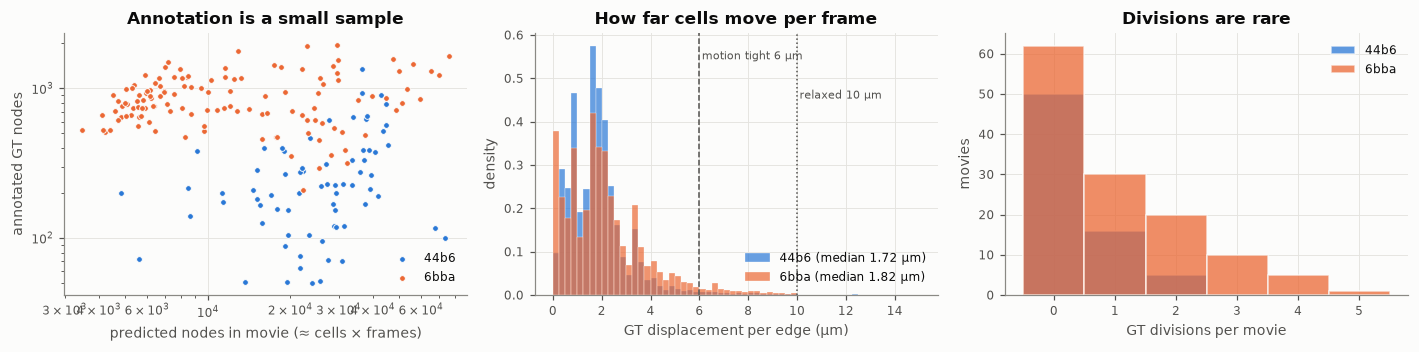

step displacement quantiles (µm): {0.5: 1.82, 0.9: 4.14, 0.99: 8.38} | share > 6 µm: 3.56% | share > 10 µm: 0.30%


In [6]:
census = pd.DataFrame(load(CENSUS / 'all_movie_results.json'))
joined = gt.merge(census[['dataset', 'num_pred_nodes', 'adjusted_edge_jaccard', 'edge_tp', 'edge_fp', 'edge_fn',
                          'div_tp', 'div_fp', 'div_fn', 'node_recall']], on='dataset')
joined['annotated_fraction'] = joined.gt_nodes / joined.num_pred_nodes
print(f"GT 노드 / 예측 노드 비율: 중앙값 {joined.annotated_fraction.median():.2%}, "
      f"10–90% 구간 {joined.annotated_fraction.quantile(.1):.2%}–{joined.annotated_fraction.quantile(.9):.2%}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
for f, g in joined.groupby('family'):
    col = FAMILY_COLOR[f]
    axes[0].scatter(g.num_pred_nodes, g.gt_nodes, s=14, color=col, label=f, edgecolor=C['surface'], linewidth=0.6)
    s = steps[steps.family == f].step_um
    axes[1].hist(s, bins=np.linspace(0, 15, 61), color=col, alpha=0.7, density=True, label=f"{f} (median {s.median():.2f} µm)", edgecolor=C['surface'], linewidth=0.3)
    axes[2].hist(g.gt_divisions, bins=np.arange(-0.5, gt.gt_divisions.max() + 1.5), color=col, alpha=0.75, label=f, edgecolor=C['surface'])
axes[0].xaxis.set_minor_formatter(plt.NullFormatter()); axes[0].yaxis.set_minor_formatter(plt.NullFormatter())
axes[0].set(xscale='log', yscale='log', xlabel='predicted nodes in movie (≈ cells × frames)', ylabel='annotated GT nodes', title='Annotation is a small sample')
axes[1].set(xlabel='GT displacement per edge (µm)', ylabel='density', title='How far cells move per frame')
for v, ls in [(6.0, '--'), (10.0, ':')]:
    axes[1].axvline(v, color=C['ink2'], lw=1, ls=ls)
axes[1].text(6.1, axes[1].get_ylim()[1] * 0.9, 'motion tight 6 µm', fontsize=7, color=C['ink2'])
axes[1].text(10.1, axes[1].get_ylim()[1] * 0.75, 'relaxed 10 µm', fontsize=7, color=C['ink2'])
axes[2].set(xlabel='GT divisions per movie', ylabel='movies', title='Divisions are rare')
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

q = steps.step_um.quantile([.5, .9, .99]).round(2).to_dict()
print('step displacement quantiles (µm):', q, '| share > 6 µm:', f"{(steps.step_um > 6).mean():.2%}", '| share > 10 µm:', f"{(steps.step_um > 10).mean():.2%}")

**데이터에서 읽히는 점**

- 주석된 노드는 예측 노드 수의 일부에 불과하다(위 비율 참조). 평가가 **주석된 궤적 주변에서만** 이루어진다는 뜻이다. 미주석 세포에 대한 예측은 대부분 채점되지 않는다.
- 한 프레임당 이동 거리는 대부분 수 µm 이내다. 후처리의 motion 재연결 기준(tight 6 µm, relaxed 10 µm)은 GT 이동 분포의 꼬리까지 덮는다. 이렇게 넓은 기준은 정답 연결을 더 가까운 대안으로 바꿔 버릴 위험도 함께 키운다(6절).
- 영상당 GT 분열은 0~수 건이다. 분열 점수(Division Jaccard)는 사건 수가 적어서 영상 몇 개에 따라 크게 흔들린다.

## 2. 평가 지표

공식 scorer(commit `075fc5f`)는 예측 노드와 GT 노드를 거리 기준으로 매칭한 뒤 다음을 계산한다.

$$\text{score} = \text{adjusted edge Jaccard} + 0.1 \times \text{division Jaccard}$$

- **Adjusted edge Jaccard**는 주석된 edge 주변에서의 연결 정확도다. 희소 주석 때문에 미매칭 예측을 일부만 벌점으로 처리하도록 보정한다. 그래서 영상 하나만 보면 1을 넘을 수 있다(아래 6.1의 분포 참조).
- **Division Jaccard**는 parent→daughter 두 개 사건의 TP/(TP+FP+FN)이다. 가중치는 0.1이지만, 이번 파이프라인에서는 후처리 전체 이득의 대부분이 이 항에서 나왔다(6.2절).
- 대회 점수는 영상별 점수의 단순 평균이 아니라 전체 집계 기반이다. 이 노트북도 집계 값을 사용한다.

## 3. 제출 이력

### 3.1 시간 순서와 Public/Private 관계

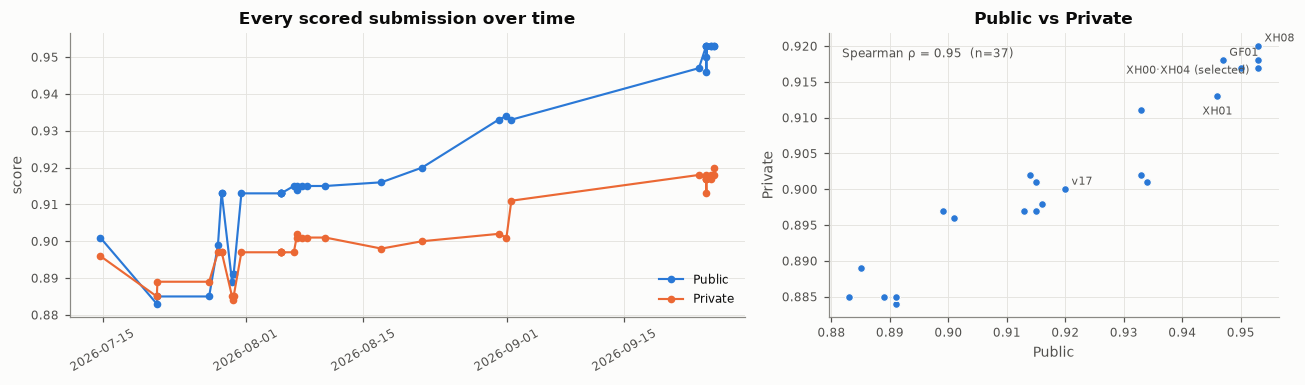

Public − Private: 중앙값 0.016, 최소 -0.004, 최대 0.036


In [7]:
s = scored.sort_values('date')
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw=dict(width_ratios=[1.5, 1]))
ax = axes[0]
ax.plot(s.date, s.publicScore, marker='o', ms=4, color=C['blue'], label='Public', lw=1.4)
ax.plot(s.date, s.privateScore, marker='o', ms=4, color=C['orange'], label='Private', lw=1.4)
ax.set(ylabel='score', title='Every scored submission over time')
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=30)

ax = axes[1]
ax.scatter(s.publicScore, s.privateScore, s=26, color=C['blue'], edgecolor=C['surface'], linewidth=0.8, zorder=3)
for _, r in s.iterrows():
    label = {'XH00': 'XH00·XH04 (selected)', 'XH08': 'XH08', 'XH01': 'XH01', 'GF01': 'GF01', 'v17': 'v17'}.get(r['tag'])
    if label:
        off, ha = {'XH00': ((-6, -4), 'right'), 'XH01': ((0, -12), 'center')}.get(r['tag'], ((4, 3), 'left'))
        ax.annotate(label, (r.publicScore, r.privateScore), xytext=off, textcoords='offset points', fontsize=7, color=C['ink2'], ha=ha)
lo, hi = s.privateScore.min() - .005, s.publicScore.max() + .005
ax.set(xlabel='Public', ylabel='Private', title='Public vs Private')
rho = s[['publicScore', 'privateScore']].corr(method='spearman').iloc[0, 1]
ax.text(0.03, 0.95, f"Spearman ρ = {rho:.2f}  (n={len(s)})", transform=ax.transAxes, fontsize=8, color=C['ink2'], va='top')
plt.tight_layout(); plt.show()

gap = (s.publicScore - s.privateScore)
print(f"Public − Private: 중앙값 {gap.median():.3f}, 최소 {gap.min():.3f}, 최대 {gap.max():.3f}")

In [8]:
top = s[s.publicScore >= 0.946][['date', 'tag', 'ref', 'publicScore', 'privateScore', 'description']].copy()
top['date'] = top['date'].dt.strftime('%m-%d')
top['selected'] = top['ref'].astype(int).map(SELECTED).notna().map({True: '✔', False: ''})
top['description'] = top['description'].str.slice(0, 60)
display(top.sort_values(['privateScore', 'publicScore'], ascending=False).style.hide(axis='index'))

date,tag,ref,publicScore,privateScore,description,selected
09-25,XH08,56554840,0.953000,0.920000,XH08 head scale 1.25 v1; direct user-authorized; rows/row_co,
09-24,XH02,56527834,0.953000,0.918000,XH02 no-flow; explicit user-authorized four-submission batch,
09-25,XH06,56542251,0.953000,0.918000,XH06 v1 audited; direct user-authorized 20260925; rows/row_c,
09-25,XH07,56554831,0.953000,0.918000,XH07 head scale 0.75 v1; direct user-authorized; rows/row_co,
09-23,GF01,56503030,0.947000,0.918000,"GF01 fixed production v1: frozen recipe, no validation sweep",
09-24,XH00,56526964,0.953000,0.917000,XH00 exact X138 reproduction control v1; explicit layout exc,✔
09-24,XH04,56527842,0.953000,0.917000,XH04 no-peak-gap; explicit user-authorized four-submission b,✔
09-25,XH05,56542248,0.953000,0.917000,XH05 v1 audited; direct user-authorized 20260925; rows/row_c,
09-24,XH03,56527838,0.950000,0.917000,XH03 no-readmit; explicit user-authorized four-submission ba,
09-24,XH01,56527827,0.946000,0.913000,XH01 no-head; explicit user-authorized four-submission batch,


- 전체 37개 제출에서는 Public과 Private의 순위 상관이 매우 강하다(Spearman ρ 0.95). **큰 개선은 Private에서도 그대로 유지됐다.**
- 그러나 Public 0.953 동점 그룹 안에서 Private은 **0.917~0.920**으로 갈렸다. 상위권의 미세한 차이는 Public 셋째 자리로 고를 수 없었다.
- Public과 Private의 차이는 중앙값 약 0.016이다. 숨겨진 Private 영상이 전반적으로 더 어렵다.
- Public 0.947이던 GF01이 Private에서는 0.918로 XH00(0.917)보다 높았다. 후반부 Public 개선 일부는 공개 테스트 4개 영상에 대한 과적합이었을 가능성이 있다.
- 최종 선택 근거였던 "low-peak gap 단계의 소폭 손실"(6.2절)은 Private에서 확인되지 않았다(XH04 = XH00 = 0.917).

### 3.2 리더보드 안에서의 위치

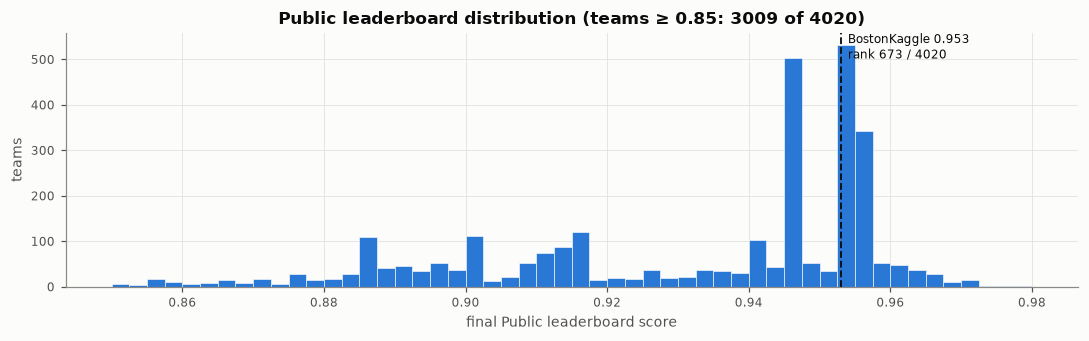

{'count': 4020.0, 'mean': 0.8276, 'std': 0.2298, 'min': 0.0, '50%': 0.92, '90%': 0.956, '99%': 0.966, 'max': 0.978}


In [9]:
fig, ax = plt.subplots(figsize=(10, 3.2))
v = lb[lb.Score >= 0.85].Score
ax.hist(v, bins=np.arange(0.85, 0.981, 0.0025), color=C['blue'], edgecolor=C['surface'], linewidth=0.4)
ax.axvline(ours.Score, color=C['ink'], lw=1.2, ls='--')
ax.text(ours.Score + 0.001, ax.get_ylim()[1] * 0.9, f"BostonKaggle {ours.Score:.3f}\nrank {int(ours.Rank)} / {len(lb)}", fontsize=8)
ax.set(xlabel='final Public leaderboard score', ylabel='teams', title=f'Public leaderboard distribution (teams ≥ 0.85: {len(v)} of {len(lb)})')
plt.tight_layout(); plt.show()
print(lb.Score.describe(percentiles=[.5, .9, .99]).round(4).to_dict())

## 4. 최종 파이프라인(X138 계열) 구조

```text
런타임 test 영상 발견 (고정 ID·CSV 재사용 금지)
  → primary / secondary Temporal 3D U-Net + Node Transformer   (두 seed, D4 TTA)
  → 검출 결합 (secondary blend 0.8) / frame retention 0.9
  → 학습된 좌표 보정 head (224→32→3 MLP, 소수 좌표 feature sampling)
  → association (harmonic weight 0.15) + ILP (SCIP, division weight 1.2, disappearance 2)
  → motion 재연결 (Hungarian: 이동거리 − 1.0 × ILP 확률, tight 5.5 µm / relaxed 10 µm, 주변 flow)
  → 버려진 검출 재허용(readmission) + 재연결
  → gap 복구 (single-frame, gap2, low-peak gap filler)
  → DeepCenter 확인을 포함한 안전 분열 복구
  → geometry / 짧은 궤적 제거 / linefit smoothing
  → 정수 CSV + 데이터셋 coverage 검사
```

공개 test 4개 영상은 T4 GPU에서 약 14분(860초) 걸렸다. 주요 학습 가중치(primary, secondary, DeepCenter, 좌표 head)는 공개 Kaggle 데이터셋에서 가져왔다. 우리 실험은 주로 **ILP 이후 후처리**와 **좌표 head 강도**를 바꿨다.

구조적 특징: motion 재연결 결과는 ILP 연결 전체를 **교체**한다(`edges = motion_edges`). ILP가 고른 연결에 대한 우대는 확률 1.0당 1 µm에 불과하다.

## 5. XH00~XH08 후처리 변형 실험

각 변형은 X138 재현(XH00)에서 한 요소만 바꿨고, 숨겨진 테스트에서 전체를 다시 실행해 채점했다. 아래 노드·연결 수는 공개 test 4개 영상의 실제 제출 CSV에서 다시 셌다.

In [10]:
VARIANTS = {
    'XH00': ('xh00_control_v1', 'X138 재현 (control)'),
    'XH01': ('xh01_no_head_v1', '좌표 head 제거'),
    'XH02': ('xh02_no_flow_v1', 'motion flow 제거'),
    'XH03': ('xh03_no_readmit_v1', 'readmission 제거'),
    'XH04': ('xh04_no_peak_gap_v1', 'low-peak gap 제거'),
    'XH05': ('xh05_local_support_v1', 'flow 지역 이웃 ≥4 요구'),
    'XH06': ('xh06_no_flow_no_peak_gap_v1', 'flow + low-peak gap 제거'),
    'XH07': ('xh07_head_scale075_v1', 'head 배율 0.75'),
    'XH08': ('xh08_head_scale125_v1', 'head 배율 1.25'),
}
def csv_stats(path):
    df = pd.read_csv(path, usecols=['dataset', 'row_type', 'source_id'])
    nodes = int((df.row_type == 'node').sum()); e = df[df.row_type == 'edge']
    return nodes, len(e), int((e.groupby(['dataset', 'source_id']).size() == 2).sum())  # node ids restart per movie

rows = []
for tag, (run, what) in VARIANTS.items():
    p = XH / 'runs' / run / 'output' / 'submission.csv'
    n, e, dv = csv_stats(p)
    r = scored[scored.tag == tag].iloc[0]
    rows.append(dict(exp=tag, change=what, public=r.publicScore, private=r.privateScore, nodes=n, edges=e, divisions=dv, sha=sha256(p)[:12]))
abl = pd.DataFrame(rows)
base = abl.iloc[0]
for k in ['nodes', 'edges', 'divisions']:
    abl[f'Δ{k}'] = abl[k] - base[k]
abl['csv = XH00'] = abl.sha.eq(base.sha).map({True: 'identical', False: ''})
display(abl.drop(columns='sha').style.hide(axis='index').format({'public': '{:.3f}', 'private': '{:.3f}'}))

exp,change,public,private,nodes,edges,divisions,Δnodes,Δedges,Δdivisions,csv = XH00
XH00,X138 재현 (control),0.953,0.917,121219,117041,62,0,0,0,identical
XH01,좌표 head 제거,0.946,0.913,124246,120038,84,3027,2997,22,
XH02,motion flow 제거,0.953,0.918,121146,116973,76,-73,-68,14,
XH03,readmission 제거,0.950,0.917,119512,115343,62,-1707,-1698,0,
XH04,low-peak gap 제거,0.953,0.917,121045,116835,62,-174,-206,0,
XH05,flow 지역 이웃 ≥4 요구,0.953,0.917,121220,117040,62,1,-1,0,
XH06,flow + low-peak gap 제거,0.953,0.918,120978,116773,76,-241,-268,14,
XH07,head 배율 0.75,0.953,0.918,122547,118357,74,1328,1316,12,
XH08,head 배율 1.25,0.953,0.920,119559,115433,56,-1660,-1608,-6,


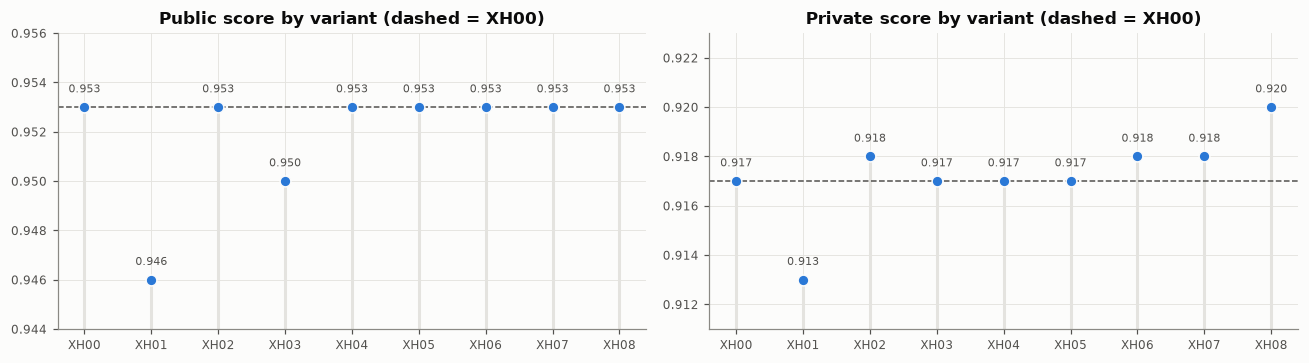

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
x = np.arange(len(abl))
for ax, col, title in [(axes[0], 'public', 'Public'), (axes[1], 'private', 'Private')]:
    ax.vlines(x, abl[col].min() - .002, abl[col], color=C['grid'], lw=2)
    ax.scatter(x, abl[col], s=50, color=C['blue'], zorder=3, edgecolor=C['surface'], linewidth=1)
    ax.axhline(base[col], color=C['ink2'], lw=1, ls='--')
    for xi, v in zip(x, abl[col]): ax.text(xi, v + .0006, f"{v:.3f}", ha='center', fontsize=7, color=C['ink2'])
    ax.set_xticks(x, abl.exp); ax.set(title=f'{title} score by variant (dashed = XH00)', ylim=(abl[col].min() - .002, abl[col].max() + .003))
plt.tight_layout(); plt.show()

**해석**

- **기능 전체를 끄면 손해였다.** 좌표 head 제거(XH01)는 Public −0.007/Private −0.004, readmission 제거(XH03)는 Public −0.003이었다.
- **XH05는 XH00과 사실상 같은 예측이다.** 노드 +1, 연결 −1 차이뿐이다. flow 지역 이웃 조건이 거의 걸리지 않았고, Public·Private 모두 XH00과 같다.
- **head 배율 1.25(XH08)가 Private 최고(0.920)였다.** 노드를 줄이는 방향(Δnodes 음수)이었다. 다만 0.003 차이는 셋째 자리 반올림 안의 두 단계 차이이고, 다른 seed나 반복 실행으로 확인하지 않았다.
- Public 0.953 동점 변형들도 노드·연결 수는 수천 개씩 달랐다. **표시 점수 동점이 같은 예측을 뜻하지 않는다.**

## 6. 오류 진단: 학습 영상 199개 전수 재채점(XH10)

XH00과 같은 가중치·설정으로 학습 영상 199개를 모두 추론했다. 최종 CSV는 로컬 공식 scorer로 다시 채점해 원격 결과와 일치함을 확인했다. 기존 가중치가 이 영상들로 학습됐을 수 있으므로 **개발 진단**으로만 쓴다.

### 6.1 전체·가족별 점수

In [12]:
ra = load(CENSUS / 'result_analysis.json')
fs = ra['final_summary']
fam_tbl = pd.DataFrame({k: ra['families'][k] for k in ['44b6', '6bba']} | {'all': fs}).T
cols = ['n', 'score', 'adjusted_edge_jaccard', 'division_jaccard', 'node_recall', 'edge_tp', 'edge_fp', 'edge_fn', 'div_tp', 'div_fp', 'div_fn']
cols = [c for c in cols if c in fam_tbl.columns]
fam_tbl.loc['all', 'edge_fp'] = fs.get('edge_fp', np.nan)
display(fam_tbl[cols].style.format(precision=4).format('{:.0f}', subset=[c for c in cols if c == 'n' or c.endswith(('_tp', '_fp', '_fn'))]))
dp = fs['div_tp'] / (fs['div_tp'] + fs['div_fp']); dr = fs['div_tp'] / (fs['div_tp'] + fs['div_fn'])
print(f"division precision {dp:.1%}, recall {dr:.1%}")

,n,score,adjusted_edge_jaccard,division_jaccard,node_recall,div_tp,div_fp,div_fn
44b6,71,0.9224,0.9134,0.0909,0.9886,4,18,22
6bba,128,0.9271,0.9155,0.1163,0.9816,20,47,105
all,199,0.9263,0.9152,0.1111,0.9841,24,65,127


division precision 27.0%, recall 15.9%


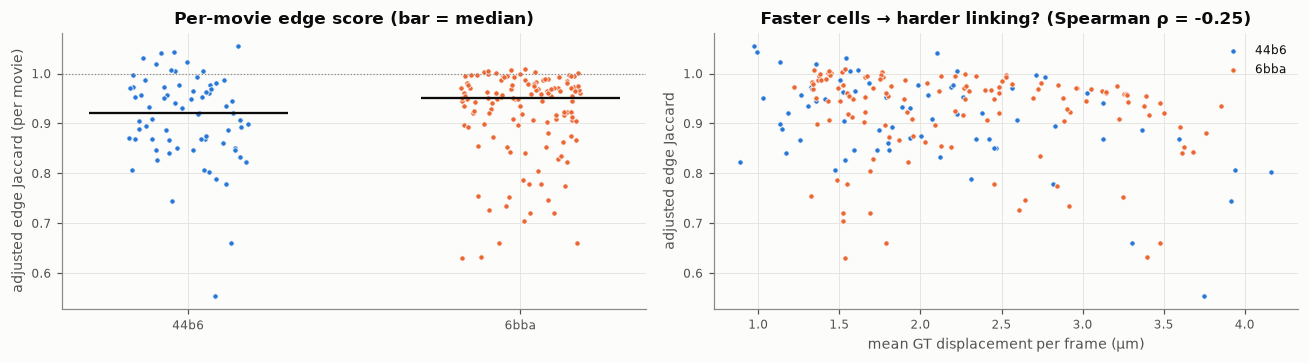

**가장 낮은 영상 8개**

dataset,family,gt_edges,mean_step_um,adjusted_edge_jaccard,edge_fp,edge_fn
44b6_87bba6c4,44b6,149,3.750000,0.554000,49,39
6bba_ebff6e76,6bba,1264,1.533000,0.631000,299,258
6bba_207c6aaf,6bba,450,3.400000,0.633000,87,93
44b6_2f31fc2f,44b6,85,3.306000,0.659000,25,14
6bba_57b7cc1e,6bba,1592,1.786000,0.660000,342,296
6bba_c73a1d11,6bba,710,3.475000,0.660000,100,147
6bba_a90a0b9c,6bba,1112,1.524000,0.705000,177,220
6bba_ab78413d,6bba,1138,1.522000,0.720000,118,194


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
ax = axes[0]
for i, (f, g) in enumerate(joined.groupby('family')):
    jitter = np.random.default_rng(0).uniform(-0.18, 0.18, len(g))
    ax.scatter(i + jitter, g.adjusted_edge_jaccard, s=12, color=FAMILY_COLOR[f], edgecolor=C['surface'], linewidth=0.5)
    ax.hlines(g.adjusted_edge_jaccard.median(), i - .3, i + .3, color=C['ink'], lw=1.5)
ax.axhline(1.0, color=C['muted'], lw=0.8, ls=':')
ax.set_xticks([0, 1], sorted(joined.family.unique()))
ax.set(ylabel='adjusted edge Jaccard (per movie)', title='Per-movie edge score (bar = median)')

ax = axes[1]
mean_step = steps.groupby('dataset').step_um.mean().rename('mean_step_um')
jj = joined.merge(mean_step, on='dataset')
for f, g in jj.groupby('family'):
    ax.scatter(g.mean_step_um, g.adjusted_edge_jaccard, s=12, color=FAMILY_COLOR[f], label=f, edgecolor=C['surface'], linewidth=0.5)
rho = jj[['mean_step_um', 'adjusted_edge_jaccard']].corr(method='spearman').iloc[0, 1]
ax.set(xlabel='mean GT displacement per frame (µm)', ylabel='adjusted edge Jaccard', title=f'Faster cells → harder linking? (Spearman ρ = {rho:.2f})')
ax.legend()
plt.tight_layout(); plt.show()

worst = jj.nsmallest(8, 'adjusted_edge_jaccard')[['dataset', 'family', 'gt_edges', 'mean_step_um', 'adjusted_edge_jaccard', 'edge_fp', 'edge_fn']]
display(Markdown('**가장 낮은 영상 8개**')); display(worst.round(3).style.hide(axis='index'))

### 6.2 후처리 단계별 변화

같은 실행에서 단계마다 스냅샷을 채점한 결과다. 모듈을 빼고 다시 실행한 인과 실험이 아니다. 단계마다 GT 매칭이 달라질 수 있다.

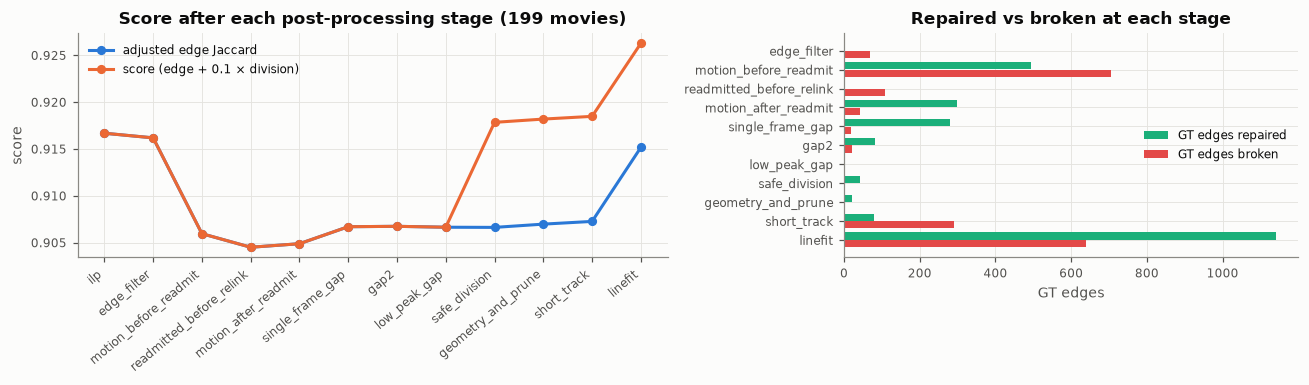

stage,score,adjusted_edge_jaccard,division_term,edge_tp,edge_fp,edge_fn,div_tp,div_fp
ilp,0.916700,0.916700,0.000000,122487,5068,6396,0,0
edge_filter,0.916200,0.916200,0.000000,122419,5066,6464,0,0
motion_before_readmit,0.906000,0.906000,0.000000,122208,6344,6675,0,0
readmitted_before_relink,0.904500,0.904500,0.000000,122102,6288,6781,0,0
motion_after_readmit,0.904900,0.904900,0.000000,122357,6512,6526,0,0
single_frame_gap,0.906700,0.906700,0.000000,122619,6488,6264,0,0
gap2,0.906700,0.906700,0.000000,122680,6521,6203,0,0
low_peak_gap,0.906600,0.906600,0.000000,122679,6528,6204,0,0
safe_division,0.917800,0.906600,0.011200,122721,6577,6162,24,63
geometry_and_prune,0.918200,0.907000,0.011200,122741,6562,6142,24,63


In [14]:
st = pd.DataFrame(ra['stage_table'])
st['division_term'] = 0.1 * st['division_jaccard']
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw=dict(width_ratios=[1.3, 1]))
ax = axes[0]
x = np.arange(len(st))
ax.plot(x, st.adjusted_edge_jaccard, marker='o', ms=5, color=C['blue'], label='adjusted edge Jaccard')
ax.plot(x, st.score, marker='o', ms=5, color=C['orange'], label='score (edge + 0.1 × division)')
ax.set_xticks(x, st.stage, rotation=40, ha='right')
ax.set(title='Score after each post-processing stage (199 movies)', ylabel='score')
ax.legend(loc='upper left')

tr = pd.DataFrame([(k, v['repaired_count'], v['broken_count']) for k, v in ra['stage_transitions'].items()],
                  columns=['transition', 'repaired', 'broken'])
tr['to'] = tr.transition.str.split(' -> ').str[1]
tr = tr.set_index('to').loc[[s for s in st.stage if s in set(tr.to)]].reset_index()
ax = axes[1]
y = np.arange(len(tr))
ax.barh(y - 0.2, tr.repaired, height=0.38, color=C['aqua'], label='GT edges repaired')
ax.barh(y + 0.2, tr.broken, height=0.38, color=C['red'], label='GT edges broken')
ax.set_yticks(y, tr.to); ax.invert_yaxis()
ax.set(xlabel='GT edges', title='Repaired vs broken at each stage')
ax.legend(loc='center right')
plt.tight_layout(); plt.show()
display(st[['stage', 'score', 'adjusted_edge_jaccard', 'division_term', 'edge_tp', 'edge_fp', 'edge_fn', 'div_tp', 'div_fp']].round(4).style.hide(axis='index'))

**해석**

- 점수가 가장 많이 떨어진 곳은 **첫 motion 재연결**이다. 정답 연결 493개를 복구했지만 704개를 깼고, adjusted edge가 약 0.010 떨어졌다. 원인은 4절에서 본 구조다. ILP 연결이 통째로 교체되고, ILP 확률 우대가 약하다.
- **분열 항은 safe-division 단계에서만 생긴다**(0 → 약 0.011). ILP의 division weight만으로는 GT 분열을 하나도 맞히지 못했다(ILP 단계 div_tp = 0).
- **마지막 linefit smoothing**은 좌표를 다듬어 매칭을 바꾼다. 연결을 1,142개 복구하고 639개를 깨서 순이득이 컸다.
- 전체 후처리는 ILP 대비 edge 항을 약간 **낮췄다**. 종합 점수가 오른 이유는 거의 전부 분열 항이다.

### 6.3 놓친 연결의 성격

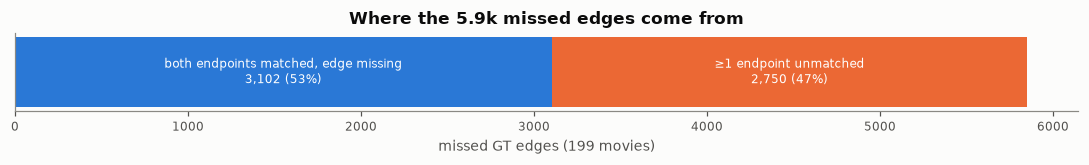

In [15]:
fn = fs['edge_fn'] if 'edge_fn' in fs else 5852
frag, lost = fs['edges_fragmented'], fs['edges_lost_to_detection']
fig, ax = plt.subplots(figsize=(10, 1.6))
ax.barh([0], [frag], color=C['blue'], height=0.5)
ax.barh([0], [lost], left=[frag], color=C['orange'], height=0.5)
ax.text(frag / 2, 0, f"both endpoints matched, edge missing\n{frag:,} ({frag / (frag + lost):.0%})", ha='center', va='center', color='white', fontsize=8)
ax.text(frag + lost / 2, 0, f"≥1 endpoint unmatched\n{lost:,} ({lost / (frag + lost):.0%})", ha='center', va='center', color='white', fontsize=8)
ax.set(yticks=[], xlabel='missed GT edges (199 movies)', title='Where the 5.9k missed edges come from'); ax.grid(False)
plt.tight_layout(); plt.show()

- 놓친 연결의 절반 이상은 **양 끝 세포를 모두 찾고도 연결을 잘못 고른** 경우다. 검출기보다 연결 선택(ILP 이후 후처리 포함)을 고치는 것이 더 직접적인 개선 경로라는 근거다.
- 나머지는 끝점 미매칭이다. 검출 누락, 위치 오차, 매칭 경쟁, 후처리 제거가 섞여 있어 모두 검출기 탓으로 돌릴 수 없다.

## 7. 사건 단위 추적(XH09, 8개 영상)

연결 확률 행렬과 후처리 단계를 사건 하나하나로 추적했다.

In [16]:
tr9 = load(XH / 'labelled_replay_2026_09_25/candidate_error_trace.json')['summary']
rows = [
    ('motion에서 사라진 GT 연결', tr9['motion_lost_gt_edge_cases']),
    ('  … 최종 출력에서도 복구 안 됨', tr9['still_lost_final']),
    ('  … 원래 연결이 target 기준 확률 1위였던 경우', tr9['original_parent_rank_1_all_captures']),
    ('  … 경쟁 연결의 확률이 원래보다 낮았던 경우 (관찰된 37건 중)', tr9['all_observed_competing_scores_lower_than_original']),
    ('  … 경쟁 연결 확률이 0.1 미만', tr9['some_observed_competing_score_below_0_1']),
]
display(pd.DataFrame(rows, columns=['motion 사건', '건수']).style.hide(axis='index'))
dv = pd.Series(tr9['division_first_provable_reason_counts']).sort_values(ascending=False).rename('건수')
display(Markdown('**놓친 분열의 첫 원인 (12건)**')); display(dv.to_frame())

motion 사건,건수
motion에서 사라진 GT 연결,39
… 최종 출력에서도 복구 안 됨,38
… 원래 연결이 target 기준 확률 1위였던 경우,39
… 경쟁 연결의 확률이 원래보다 낮았던 경우 (관찰된 37건 중),33
… 경쟁 연결 확률이 0.1 미만,23


**놓친 분열의 첫 원인 (12건)**

,건수
second_daughter_already_has_incoming_edge,5
missing_or_ambiguous_endpoint_before_division,3
accepted_by_original_safe_division,2
later_deepcenter_symmetry_or_proposal_selection_unresolved,1
second_daughter_not_nearest_free_sister,1


- motion이 깬 정답 연결 39건은 **모두** association 모델이 그 target의 1순위로 꼽은 연결이었다. 확인 가능한 37건 중 33건은 이를 대체한 연결의 모델 확률이 더 낮았다. **학습된 모델은 맞혔는데 기하 규칙이 덮어쓴 것이다.**
- 놓친 분열의 가장 흔한 원인은 "두 번째 딸세포가 이미 다른 parent에 연결돼 있음"이다. 일반 연결을 먼저 확정하고 분열을 나중에 복구하는 순서가 정답을 막는다.

## 8. 자체 기준선 학습(XH11 B0)

공개 가중치에 의존하지 않는 기준선을 random initialization에서 학습했다. 한 가족으로 학습하고 다른 가족에서 평가하는 source-only 방식이다. Temporal 3D U-Net `[32,64,128]`, 2-frame 문맥, AdamW 1e-4, batch 4로 학습했다.

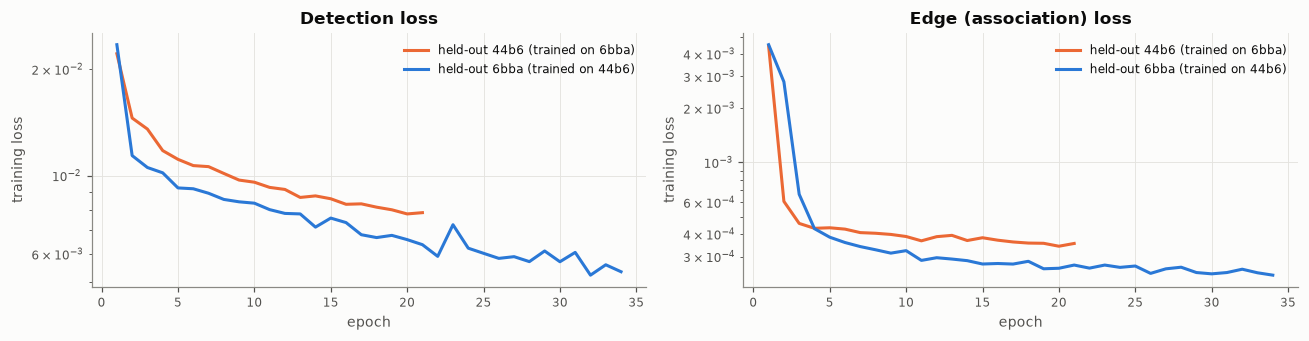

,epochs,hours,last_det,last_edge
hold,,,,
44b6,21,28.7,0.007860,0.000355
6bba,34,28.3,0.005349,0.000237


In [17]:
hist = []
for d in sorted((XH / 'source_baselines_2026_09_26/collected').glob('*/v1/b0_training/training_history.json')):
    name = d.parents[2].name
    hold = '44b6' if 'hold-44b6' in name else '6bba'
    for r in load(d):
        hist.append(dict(run=name, hold=hold, **r))
hist = pd.DataFrame(hist).sort_values(['hold', 'epoch']).drop_duplicates(['hold', 'epoch'], keep='last')
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
for hold, g in hist.groupby('hold'):
    lab = f"held-out {hold} (trained on {'6bba' if hold == '44b6' else '44b6'})"
    col = FAMILY_COLOR['6bba' if hold == '44b6' else '44b6']
    axes[0].plot(g.epoch, g.detection_loss, color=col, label=lab)
    axes[1].plot(g.epoch, g.edge_loss, color=col, label=lab)
axes[0].set(yscale='log', xlabel='epoch', ylabel='training loss', title='Detection loss')
axes[1].set(yscale='log', xlabel='epoch', ylabel='training loss', title='Edge (association) loss')
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()
display(hist.groupby('hold').agg(epochs=('epoch', 'max'), hours=('seconds', lambda s: round(s.sum() / 3600, 1)),
                                 last_det=('detection_loss', 'last'), last_edge=('edge_loss', 'last')))

- 학습 손실은 계속 줄었지만, 두 모델은 50 epoch 목표 중 21·34 epoch에서 멈췄다. epoch당 약 50분(44b6 71개로 학습)~82분(6bba 128개로 학습)이 걸렸다(Kaggle GPU).
- 이 체크포인트로 만든 CPU 제출(ref 56621729)은 숨겨진 테스트에서 **실행 시간 초과**로 점수를 받지 못했다. 경량판(TTA 제거, 37분)은 저장소의 행 수 계약에 막혀 제출하지 않았다.
- 학습 손실만으로는 추적 점수를 알 수 없다. 중간 체크포인트의 공식 추적 평가는 GPU 할당량 부족으로 끝내지 못했다.

## 9. 교훈과 다음 연구

**무엇이 효과가 있었나**

1. 강한 공개 파이프라인을 byte 단위로 재현하고 감사하기. 이후 모든 비교의 기준점이 됐다.
2. 좌표 head와 readmission 유지. 둘 다 끄면 점수가 떨어졌다.
3. 199개 영상 전수 재채점과 사건 추적. 개선 방향(연결 선택, 분열)을 데이터로 좁혔다.

**무엇이 부족했나**

1. **Public 셋째 자리 동점 안에서 후처리 문턱만 바꾼 실험이 많았다.** 진단에서 찾은 병목(motion의 정답 연결 교체, 분열 순서)을 직접 고치는 모델은 마감 전에 완성하지 못했다.
2. **GPU 할당량 관리.** 마지막 주에 주간 한도(45시간)를 넘겨, 마감 직전 후보를 실행할 수 없었다.
3. **상위권 미세 차이의 판별력 부족.** 전체적으로는 Public과 Private이 강하게 상관했다(ρ 0.95). 하지만 0.953 동점 그룹 안의 선택은 사실상 운이었다. 최종 선택에는 Public 외에 반복 가능한 개발 검증 근거가 필요하다.
4. **제출 형식 계약(고정 행 수)이 새 모델 제출을 구조적으로 막았다.** 예측 노드 수가 바뀌는 모든 후보가 예외 승인을 받아야 했다.

**다음 연구 우선순위** (대회 후)

| 순서 | 실험 | 근거 |
|---|---|---|
| 1 | motion 재연결의 ILP 우대(`MOTION_RELINK_LEARNED_BONUS`) 상향, 또는 ILP 연결 유지·교체 분류기 | 6.2, 7절: 정답을 깬 39건 모두 모델 1순위 |
| 2 | 일반 연결과 분열의 공동 선택(parent + 두 daughter를 한 사건으로) | 7절: 두 번째 딸세포가 이미 연결된 경우가 최다 |
| 3 | 놓친 연결의 끝점 미매칭 47% 분해: 검출 부재 / 위치 오차 / 매칭 경쟁 | 6.3절 |
| 4 | 좌표 head 배율·학습 재검토 | 5절: 1.25 배율이 Private 최고 |

1번은 학습 영상 66개에 대해 저장된 ILP 이전 연결 확률 행렬(`full_census_2026_09_25/xh10_full_census_a/output_v1/xh09_observations`)로 GPU 없이 바로 비교할 수 있다.